In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import (auc, f1_score, roc_curve, roc_auc_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from scipy.stats import ttest_rel
import missingno as msno
from scipy.stats import chi2_contingency

# DATA ACQUISITION

In [67]:
# dataset path definition
dataset_path = "../data/raw/capture20110815-2.csv"
df = pd.read_csv(dataset_path)

# DATA EXPLORATION

In [68]:
print(f"Dimension of dataset: {df.shape}")

Dimension of dataset: (129832, 15)


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 129832 entries, 0 to 129831
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   StartTime  129832 non-null  str    
 1   Dur        129832 non-null  float64
 2   Proto      129832 non-null  str    
 3   SrcAddr    129832 non-null  str    
 4   Sport      129035 non-null  str    
 5   Dir        129832 non-null  str    
 6   DstAddr    129832 non-null  str    
 7   Dport      129455 non-null  str    
 8   State      129832 non-null  str    
 9   sTos       128974 non-null  float64
 10  dTos       122936 non-null  float64
 11  TotPkts    129832 non-null  int64  
 12  TotBytes   129832 non-null  int64  
 13  SrcBytes   129832 non-null  int64  
 14  Label      129832 non-null  str    
dtypes: float64(3), int64(3), str(9)
memory usage: 14.9 MB


In [70]:
df.head(5)

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/15 16:43:28.078942,0.000000,tcp,114.33.245.44,6881,?>,147.32.84.118,1567,RA_,0.0,0.0,1,60,60,flow=Background
1,2011/08/15 16:43:32.283576,13.431962,tcp,212.93.105.52,49237,->,147.32.84.229,80,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
2,2011/08/15 16:43:32.456441,13.350228,tcp,212.93.105.52,14906,->,147.32.84.229,13363,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
3,2011/08/15 16:43:32.850648,13.010090,tcp,212.93.105.52,60349,->,147.32.84.229,443,SRA_SA,0.0,0.0,6,388,208,flow=Background-TCP-Established
4,2011/08/15 16:45:09.305002,20.990047,tcp,115.127.24.116,3198,->,147.32.84.229,443,SR_SA,0.0,0.0,5,308,122,flow=Background-TCP-Established


<Axes: xlabel='Label'>

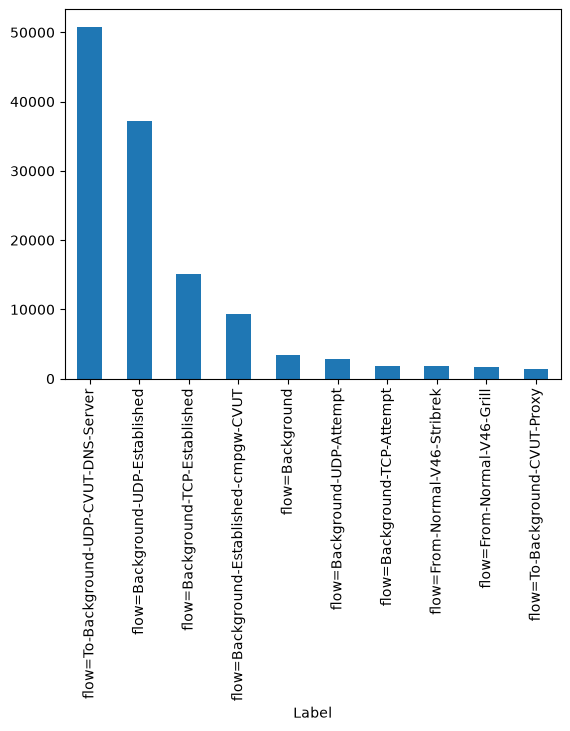

In [71]:
df['Label'].value_counts().head(10).plot(kind='bar')

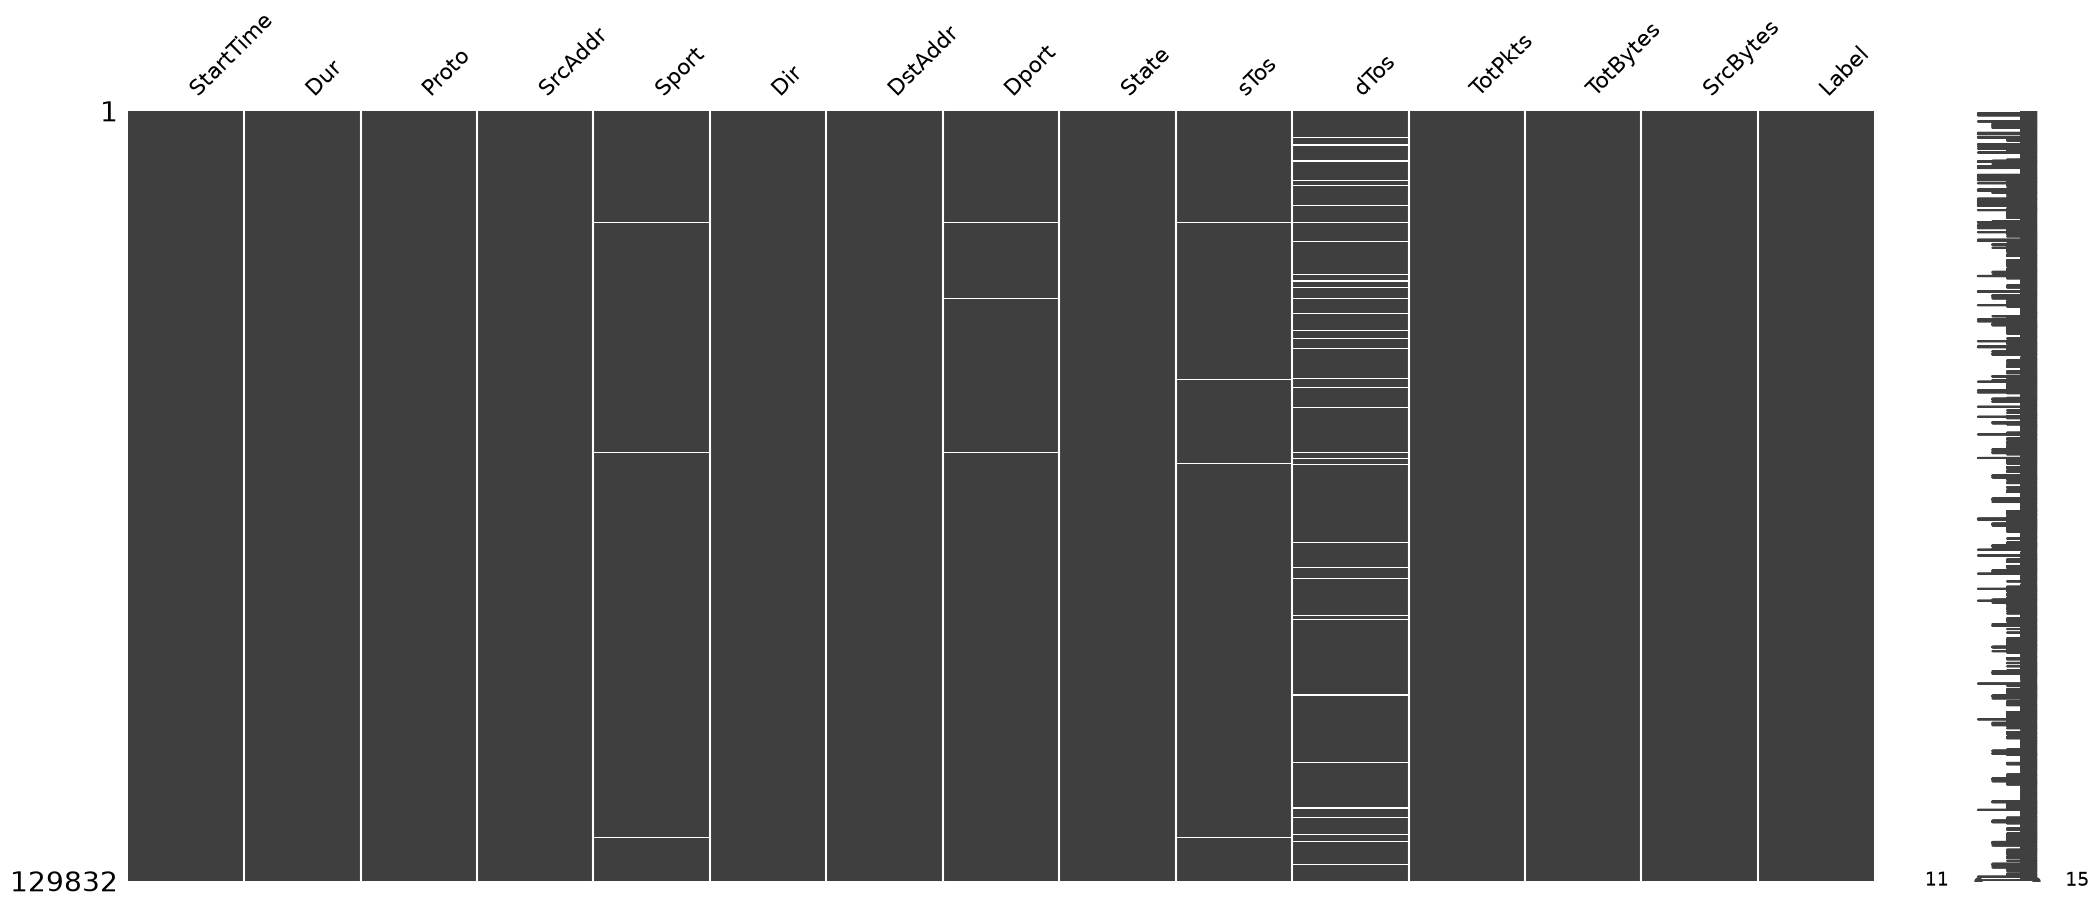

In [72]:
msno.matrix(df)
plt.show()

# DATA PREPROCESSING

## DATA CLEANING

In [73]:
#decimal conversion Dport
for col in ['Dport']:
  df[col] = df[col].replace(r'^\s*$', np.nan, regex=True) #replace empty strings with NaN

## DATA MURGING

In [74]:
#target mapping
df['Target'] = (df['Label'].astype(str).str.contains('Botnet', case=False, regex=False)).astype(int)

target_counts = df['Target'].value_counts()
target_props = df['Target'].value_counts(normalize=True) * 100

print ("Distribuition after binary mapping (Target):")
print(f"Class 0 (Normal/Background): {target_counts.get(0, 0):,} ({target_props.get(0, 0):.2f}%)")
print(f"Class 1 (Botnet): {target_counts.get(1, 0):,} ({target_props.get(1, 0):.2f}%)")

# Pulizia delle stringhe
categorical_cols = df.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

Distribuition after binary mapping (Target):
Class 0 (Normal/Background): 128,931 (99.31%)
Class 1 (Botnet): 901 (0.69%)


### DATA EXPLORATION - VISUALIZATION

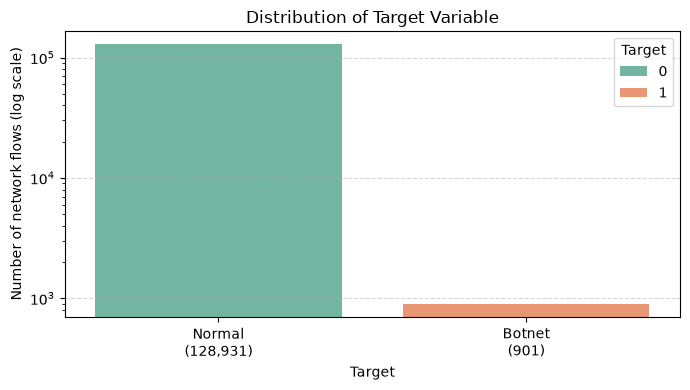

In [55]:
plt.figure(figsize=(7, 4))

ax = sns.countplot(x='Target', hue='Target', data=df, palette='Set2')

ax.set_yscale('log')
ax.set_title('Distribution of Target Variable')
ax.set_ylabel('Number of network flows (log scale)')
plt.xticks([0, 1],[f"Normal\n({target_counts.get(0, 0):,})", f"Botnet\n({target_counts.get(1, 0):,})",],)


plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



--- Numerical features check ---
Feature 'Dur': 59844 unique values
Feature 'TotPkts': 802 unique values
Feature 'SrcBytes': 7041 unique values


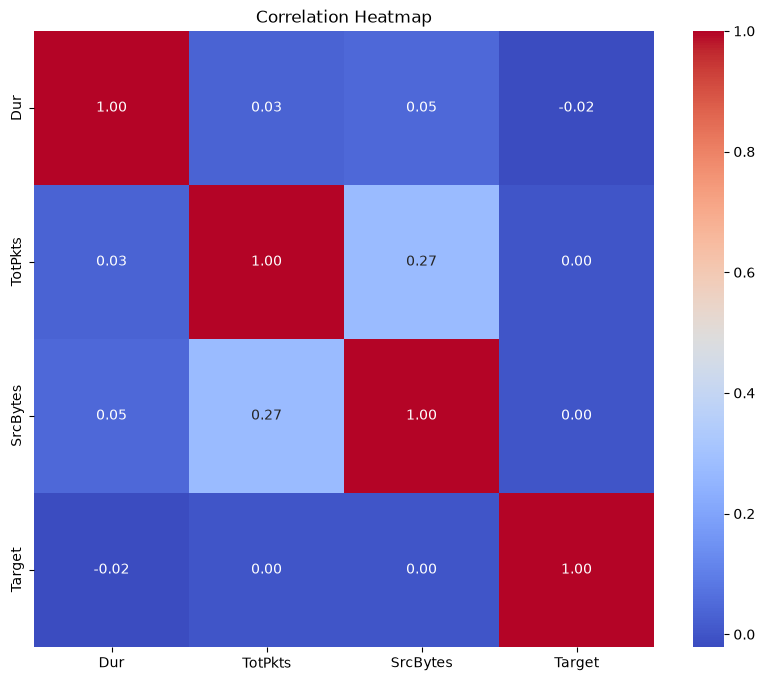


--- Descriptive statistics by Target ---
Target                      0              1
Dur      median  7.190000e-04       1.592649
         mean    7.793546e+01       6.489200
         std     2.831898e+02      43.092420
         max     1.805828e+03    1139.728638
TotPkts  median  2.000000e+00       6.000000
         mean    3.451280e+01      34.819090
         std     2.502953e+03      78.786008
         max     6.945530e+05     678.000000
SrcBytes median  8.100000e+01     186.000000
         mean    5.040658e+03   10965.527192
         std     5.197573e+05   49864.479033
         max     1.365468e+08  600198.000000


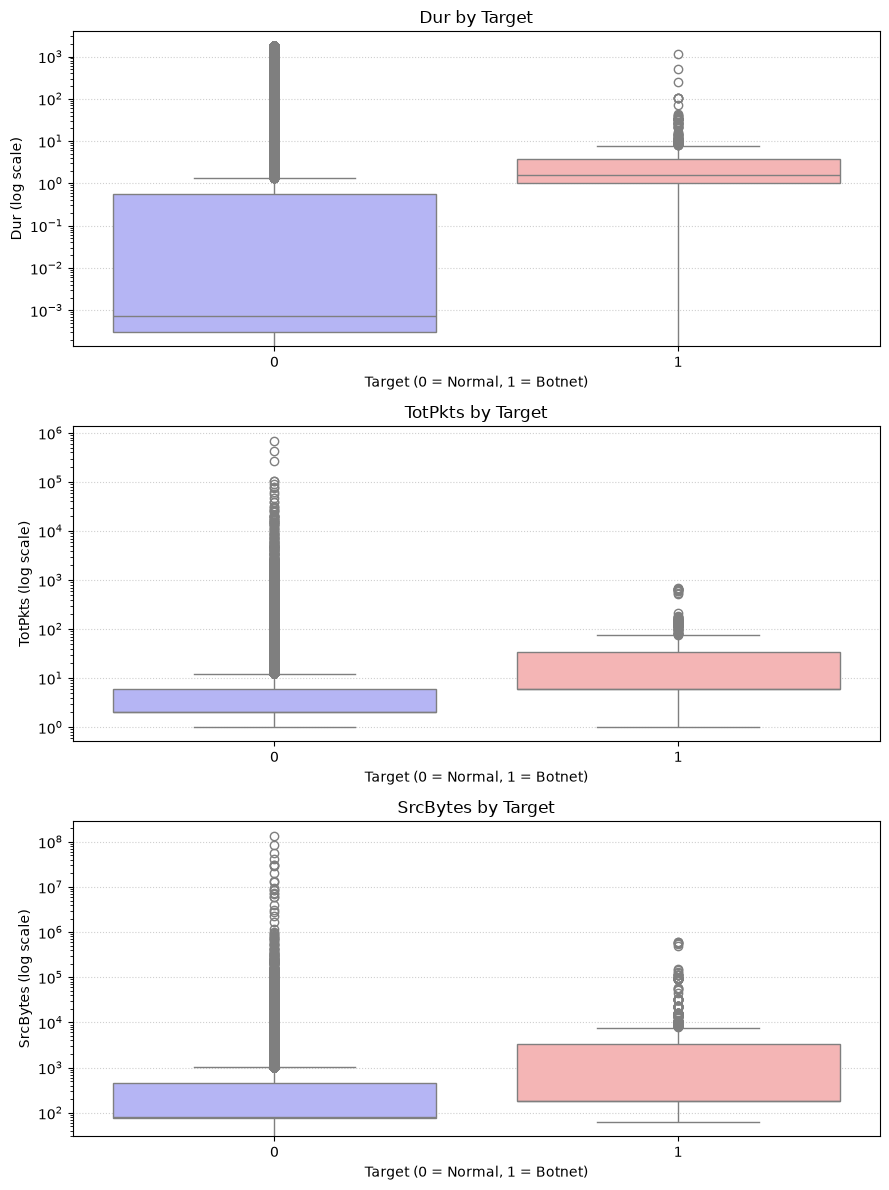

In [78]:
numerical_features = ['Dur', 'TotPkts', 'SrcBytes']

print("\n--- Numerical features check ---")
for col in numerical_features:
    number_unique = df[col].nunique()
    print(f"Feature '{col}': {number_unique} unique values")

#numerical features conversion, coerce to Nan if conversion fails
for col in numerical_features:
  df[col] = pd.to_numeric(df[col], errors='coerce')

#heatmap correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Dur', 'TotPkts', 'SrcBytes', 'Target']].corr(), annot=True, cmap='coolwarm', fmt='.2f',)
plt.title('Correlation Heatmap')
plt.show()

if numerical_features:
    print('\n--- Descriptive statistics by Target ---')
    print(
        df.groupby('Target')[numerical_features].agg(['median', 'mean', 'std', 'max']).T)
    # Boxplots
    fig, axes = plt.subplots(len(numerical_features), 1,figsize=(9, 4 * len(numerical_features)))
    for ax, col in zip(axes, numerical_features):
      sns.boxplot(data=df,x='Target',y=col,hue='Target',palette='bwr',legend=False,ax=ax)
      ax.set_yscale('log')
      ax.set_title(f'{col} by Target')
      ax.set_xlabel('Target (0 = Normal, 1 = Botnet)')
      ax.set_ylabel(f'{col} (log scale)')
      ax.grid(axis='y', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

## DATA MUNGING

In [79]:
for col in ['Dport']:
  df[col] = df[col].apply(
    lambda x: (int(str(x), 16)
    if pd.notna(x) and str(x).strip().lower().startswith('0x')
    else x
    )
  )

  df[col] = pd.to_numeric(df[col], errors='coerce') #convert to numeric, coerce errors to NaN

def categorize_port(port):
    """Categorizza le porte secondo lo standard IANA."""
    if pd.isna(port):
        return 'Missing'
    elif 0 <= port <= 1023:
        return 'Well-Known'
    elif 1024 <= port <= 49151:
        return 'Registered'
    elif 49152 <= port <= 65535:
        return 'Dynamic'
    else:
        return 'Invalid'

df['Dport_cat'] = df['Dport'].apply(categorize_port)
df['Dport'] = df['Dport'].fillna(-1).astype(int).astype(str) #replace NaN with -1, conversion to str

categorical_features = ['Proto', 'State', 'Dport', 'Dport_cat']
print("\n--- Categorical features check ---")
for col in categorical_features:
    number_unique = df[col].nunique()
    print(f"Feature '{col}': {number_unique} unique values")

Dport_category = df['Dport_cat'].value_counts()


--- Categorical features check ---
Feature 'Proto': 11 unique values
Feature 'State': 155 unique values
Feature 'Dport': 12013 unique values
Feature 'Dport_cat': 4 unique values


In [84]:
# Test del Chi2 direttamente tra una feature categoriale (es. Dport_cat) e il Target
for col in ['Proto', 'State', 'Dport', 'Dport_cat']:
    contingency_table = pd.crosstab(df[col], df['Target'])
    chi2_stat, p_val, dof, _ = chi2_contingency(contingency_table)
    
    print(f"--- Test Chi2 for {col} ---")
    print(f"Chi2 Statistic: {chi2_stat:.4f}")
    print(f"p-value: {p_val:.4e}")
    if p_val < 0.05:
        print(f"Risultato: Dipendenza statisticamente significativa con il Target (p < 0.05)\n")
    else:
        print(f"Risultato: Nessuna dipendenza significativa\n")

--- Test Chi2 for Proto ---
Chi2 Statistic: 2375.6462
p-value: 0.0000e+00
Risultato: Dipendenza statisticamente significativa con il Target (p < 0.05)

--- Test Chi2 for State ---
Chi2 Statistic: 13451.9699
p-value: 0.0000e+00
Risultato: Dipendenza statisticamente significativa con il Target (p < 0.05)

--- Test Chi2 for Dport ---
Chi2 Statistic: 50119.4916
p-value: 0.0000e+00
Risultato: Dipendenza statisticamente significativa con il Target (p < 0.05)

--- Test Chi2 for Dport_cat ---
Chi2 Statistic: 709.7200
p-value: 1.6381e-153
Risultato: Dipendenza statisticamente significativa con il Target (p < 0.05)



### DATA VISUALIZATION

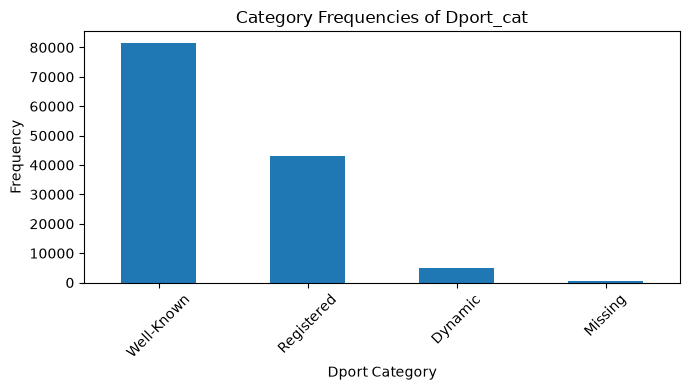

In [58]:
plt.figure(figsize=(7, 4))
Dport_category.plot(kind='bar')

plt.xlabel('Dport Category')
plt.ylabel('Frequency')
plt.title('Category Frequencies of Dport_cat')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## DATA TRASFORMATION

In [59]:
#remove columns probably data leakage
cols_to_drop = ['Label', 'Target', 'Dir', 'SrcAddr', 'DstAddr', 'Sport', 'sTos', 'dTos', 'StartTime', 'TotBytes']
#definition of X: features, y: target
X = df.drop(columns=cols_to_drop)
y = df['Target']

categorical_features_raw = ['Proto', 'State', 'Dport']
categorical_features_cat = ['Proto', 'State', 'Dport_cat']

print(f"Selected numerical features: {numerical_features}")
print(f"Selected categorical features (raw): {categorical_features_raw}")
print(f"Selected categorical features (IANA): {categorical_features_cat}")

Selected numerical features: ['Dur', 'TotPkts', 'SrcBytes']
Selected categorical features (raw): ['Proto', 'State', 'Dport']
Selected categorical features (IANA): ['Proto', 'State', 'Dport_cat']


In [60]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)) #activate sparse matrix for memory efficiency
])


preprocessor_raw = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features_raw)
    ],
    remainder='drop'
)

preprocessor_cat = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features_cat)
    ],
    remainder='drop'
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# DATA PROCESSING / MODELLING

In [61]:
#RANDOM FOREST cost sensitive learning
rf_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor_raw),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', #major weight to minority class
        max_depth=None, #limit depth to avoid overfitting
        random_state=42, 
        n_jobs=-1
    ))
])

rf_pipeline_cat = Pipeline(steps=[
    ('preprocessor', preprocessor_cat),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', #major weight to minority class
        max_depth=None, #limit depth to avoid overfitting
        random_state=42, 
        n_jobs=-1
    ))
])

#LOGISTIC REGRESSION
lr_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor_raw),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, #maximum iterations for convergence
        random_state=42
    ))
])

lr_pipeline_cat = Pipeline(steps=[
    ('preprocessor', preprocessor_cat),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        max_iter=1000, #maximum iterations for convergence
        random_state=42
    ))
])

#DECISION TREE
dt_pipeline_raw = Pipeline(steps=[
    ('preprocessor', preprocessor_raw),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced', #unbalanced compensation
        max_depth=None, #limit depth to avoid overfitting
        random_state=42
    ))
])

dt_pipeline_cat = Pipeline(steps=[
    ('preprocessor', preprocessor_cat),
    ('classifier', DecisionTreeClassifier(
        class_weight='balanced', #unbalanced compensation
        max_depth=None, #limit depth to avoid overfitting
        random_state=42
    ))
])

print("Pipelines created successfully.")

Pipelines created successfully.


# MODEL EVALUATION

Evaluation in progress for Random Forest...
Evaluation in progress for Logistic Regression...
Evaluation in progress for Decision Tree...

================ COMPARATIVE PERFORMANCE TABLE ================
              Model Precision (Botnet) Recall (Botnet) F1-Score (Botnet)         ROC-AUC
      Random Forest    0.8993 ± 0.0192 0.8868 ± 0.0309   0.8926 ± 0.0156 0.9714 ± 0.0128
Logistic Regression    0.0539 ± 0.0021 0.9368 ± 0.0186   0.1020 ± 0.0039 0.9565 ± 0.0123
      Decision Tree    0.8699 ± 0.0234 0.8646 ± 0.0423   0.8666 ± 0.0248 0.9318 ± 0.0232



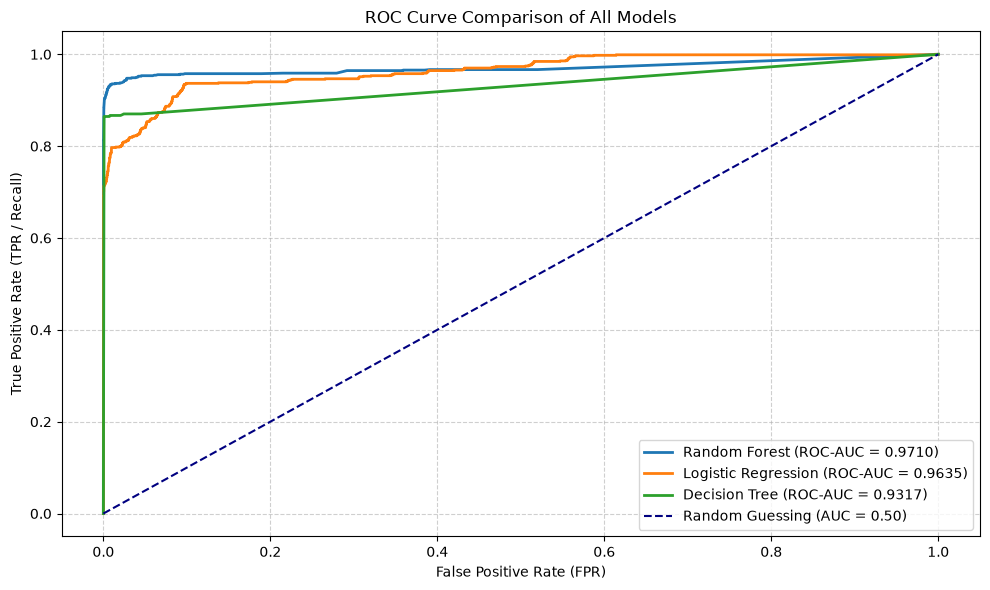

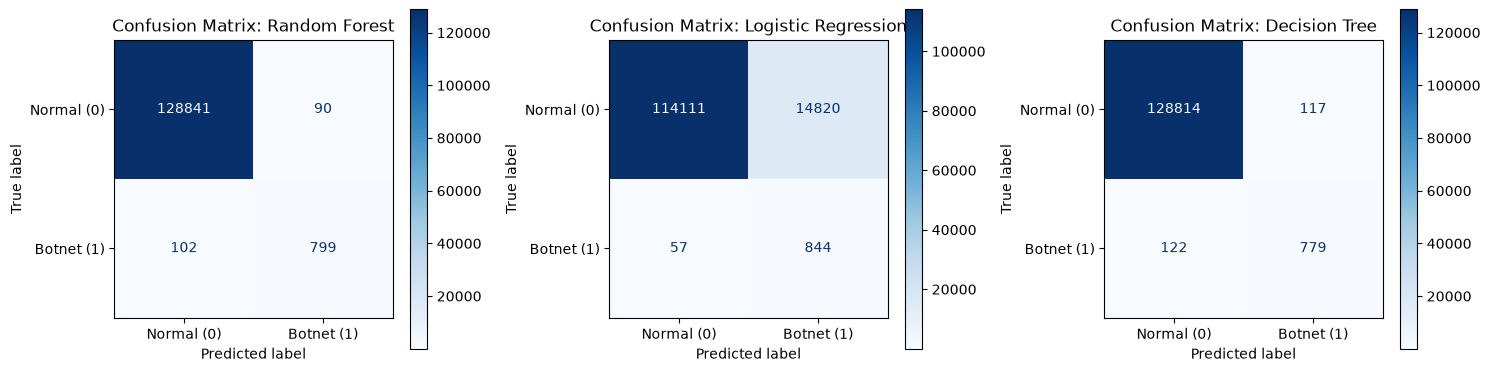

In [62]:
models = {
    'Random Forest': rf_pipeline_raw,
    'Logistic Regression': lr_pipeline_raw,
    'Decision Tree': dt_pipeline_raw,
}

# 10-fold stratified cross-validation, shuffle=True to randomize data order
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results_list = []
# dict to save predictions for confusion matrix
y_predicted_dict = {}

# salvo metriche per ogni fold per ogni modello
fold_metrics_dict = {}

plt.figure(figsize=(10, 6))

for name, pipeline in models.items():
    print(f"Evaluation in progress for {name}...")

    y_predicted = cross_val_predict(pipeline, X, y, cv=skf, method='predict', n_jobs=-1)
    # botnet probability
    y_probability = cross_val_predict(pipeline, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

    # save predictions for confusion matrix
    y_predicted_dict[name] = y_predicted

    # metric calculation for each fold
    fold_precision, fold_recalls, fold_f1s, fold_roc_auc = [], [], [], []

    # training set already calculated
    for _, test_idx in skf.split(X, y):
        y_test_fold = y.iloc[test_idx]
        # predictions and probabilities for the current fold
        y_predicted_fold = y_predicted[test_idx]
        y_probability_fold = y_probability[test_idx]

        fold_precision.append(precision_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
        fold_recalls.append(recall_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
        fold_f1s.append(f1_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))

        # ROC-AUC computation based on probabilities for the current fold
        fpr_fold, tpr_fold, _ = roc_curve(y_test_fold, y_probability_fold)
        fold_roc_auc.append(auc(fpr_fold, tpr_fold))

    # save fold metrics for the current model
    fold_metrics_dict[name] = {
        'F1-Score (Botnet)': fold_f1s,
        'ROC-AUC': fold_roc_auc
    }

    # Overall ROC Curve calculation
    fpr, tpr, _ = roc_curve(y, y_probability)
    overall_roc_auc = auc(fpr, tpr)

    results_list.append({
        'Model': name,
        'Precision (Botnet)': f"{np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}",
        'Recall (Botnet)': f"{np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}",
        'F1-Score (Botnet)': f"{np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}",
        'ROC-AUC': f"{np.mean(fold_roc_auc):.4f} ± {np.std(fold_roc_auc):.4f}",
        'ROC-AUC_sort': np.mean(fold_roc_auc),
    })

    # ROC Curve Plot
    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (ROC-AUC = {overall_roc_auc:.4f})'
    )

# Baseline per classificatore casuale nella ROC Curve
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guessing (AUC = 0.50)')

# comparative table
df_results = pd.DataFrame(results_list).sort_values(by='ROC-AUC_sort', ascending=False).drop(columns=['ROC-AUC_sort'])

print('\n================ COMPARATIVE PERFORMANCE TABLE ================')
print(df_results.to_string(index=False))
print('=======================================================================\n')

# ROC Curve plot formatting
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('ROC Curve Comparison of All Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# output confusion matrix
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
axes = axes.flatten()

for i, (name, y_predicted) in enumerate(y_predicted_dict.items()):
    cm = confusion_matrix(y, y_predicted)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Botnet (1)'])
    display.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()

Grouped Bar Plot

In [63]:
print('\n================ STATISTICAL SIGNIFICANCE (PAIRED T-TEST) ================')

model1 = 'Random Forest' 
model2 = 'Decision Tree'             

metric_to_test = 'F1-Score (Botnet)'

m1_scores = fold_metrics_dict[model1][metric_to_test]
m2_scores = fold_metrics_dict[model2][metric_to_test]



t_stat, p_val = ttest_rel(m1_scores, m2_scores)

print(f"Comparing: {model1} vs {model2}")
print(f"Metric Evaluated: {metric_to_test}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print(f"Conclusion: The performance difference is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print(f"Conclusion: The performance difference is NOT statistically significant (p >= 0.05).")
print('==========================================================================\n')


================ STATISTICAL SIGNIFICANCE (PAIRED T-TEST) ================
Comparing: Random Forest vs Decision Tree
Metric Evaluated: F1-Score (Botnet)
T-statistic: 3.9692
P-value: 0.0033
Conclusion: The performance difference is STATISTICALLY SIGNIFICANT (p < 0.05).



Evaluation in progress for Random Forest (Categorized)...
Evaluation in progress for Logistic Regression (Categorized)...
Evaluation in progress for Decision Tree (Categorized)...

================ COMPARATIVE PERFORMANCE TABLE ================
                            Model Precision (Botnet) Recall (Botnet) F1-Score (Botnet)         ROC-AUC
      Random Forest (Categorized)    0.7605 ± 0.0468 0.8057 ± 0.0446   0.7816 ± 0.0375 0.9596 ± 0.0086
Logistic Regression (Categorized)    0.0444 ± 0.0013 0.9256 ± 0.0217   0.0848 ± 0.0024 0.9382 ± 0.0151
      Decision Tree (Categorized)    0.7728 ± 0.0301 0.7469 ± 0.0461   0.7583 ± 0.0224 0.8700 ± 0.0245



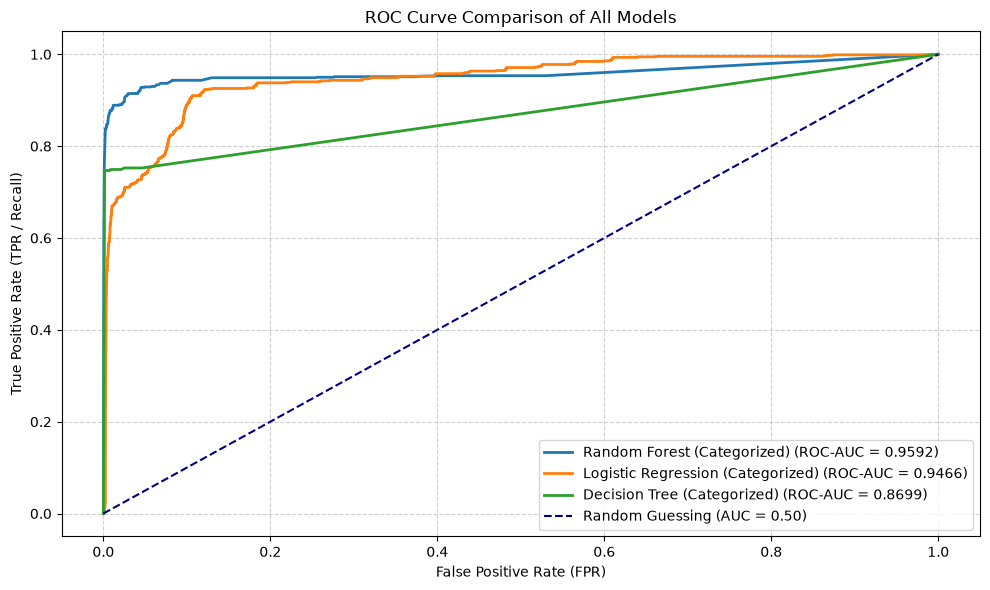

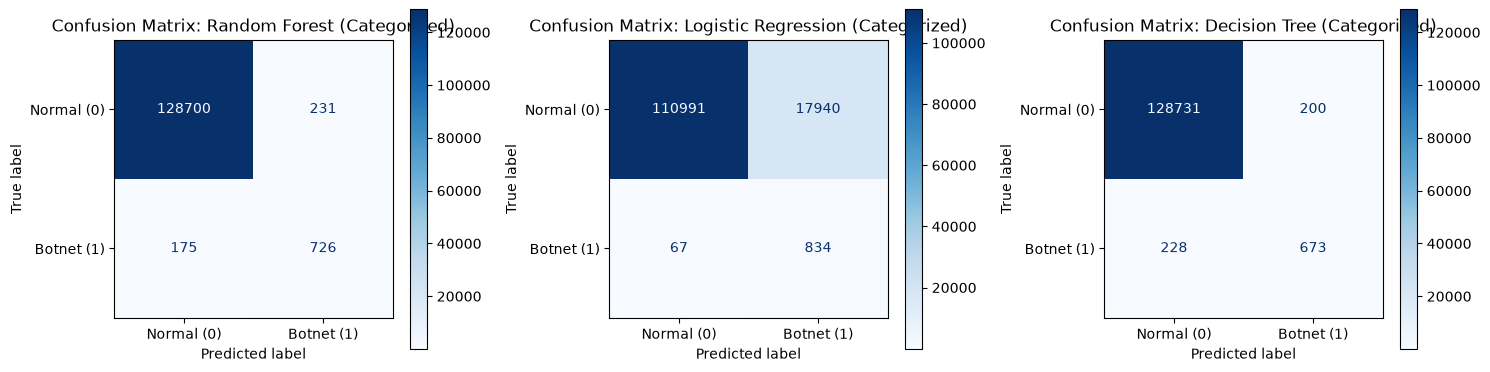

In [65]:
models_categorized = {
    'Random Forest (Categorized)': rf_pipeline_cat,
    'Logistic Regression (Categorized)': lr_pipeline_cat,
    'Decision Tree (Categorized)': dt_pipeline_cat,
}
# 10-fold stratified cross-validation, shuffle=True to randomize data order
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results_list = []
# dict to save predictions for confusion matrix
y_predicted_dict = {}

# salvo metriche per ogni fold per ogni modello
fold_metrics_dict = {}

plt.figure(figsize=(10, 6))

for name, pipeline in models_categorized.items():
    print(f"Evaluation in progress for {name}...")

    y_predicted = cross_val_predict(pipeline, X, y, cv=skf, method='predict', n_jobs=-1)
    # botnet probability
    y_probability = cross_val_predict(pipeline, X, y, cv=skf, method='predict_proba', n_jobs=-1)[:, 1]

    # save predictions for confusion matrix
    y_predicted_dict[name] = y_predicted

    # metric calculation for each fold
    fold_precision, fold_recalls, fold_f1s, fold_roc_auc = [], [], [], []

    # training set already calculated
    for _, test_idx in skf.split(X, y):
        y_test_fold = y.iloc[test_idx]
        # predictions and probabilities for the current fold
        y_predicted_fold = y_predicted[test_idx]
        y_probability_fold = y_probability[test_idx]

        fold_precision.append(precision_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
        fold_recalls.append(recall_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))
        fold_f1s.append(f1_score(y_test_fold, y_predicted_fold, pos_label=1, zero_division=0))

        # ROC-AUC computation based on probabilities for the current fold
        fpr_fold, tpr_fold, _ = roc_curve(y_test_fold, y_probability_fold)
        fold_roc_auc.append(auc(fpr_fold, tpr_fold))

    # save fold metrics for the current model
    fold_metrics_dict[name] = {
        'F1-Score (Botnet)': fold_f1s,
        'ROC-AUC': fold_roc_auc
    }

    # Overall ROC Curve calculation
    fpr, tpr, _ = roc_curve(y, y_probability)
    overall_roc_auc = auc(fpr, tpr)

    results_list.append({
        'Model': name,
        'Precision (Botnet)': f"{np.mean(fold_precision):.4f} ± {np.std(fold_precision):.4f}",
        'Recall (Botnet)': f"{np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}",
        'F1-Score (Botnet)': f"{np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}",
        'ROC-AUC': f"{np.mean(fold_roc_auc):.4f} ± {np.std(fold_roc_auc):.4f}",
        'ROC-AUC_sort': np.mean(fold_roc_auc),
    })

    # ROC Curve Plot
    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{name} (ROC-AUC = {overall_roc_auc:.4f})'
    )

# Baseline per classificatore casuale nella ROC Curve
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guessing (AUC = 0.50)')

# comparative table
df_results = pd.DataFrame(results_list).sort_values(by='ROC-AUC_sort', ascending=False).drop(columns=['ROC-AUC_sort'])

print('\n================ COMPARATIVE PERFORMANCE TABLE ================')
print(df_results.to_string(index=False))
print('=======================================================================\n')

# ROC Curve plot formatting
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('ROC Curve Comparison of All Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# output confusion matrix
fig, axes = plt.subplots(1, len(models_categorized), figsize=(5 * len(models_categorized), 4))
axes = axes.flatten()

for i, (name, y_predicted) in enumerate(y_predicted_dict.items()):
    cm = confusion_matrix(y, y_predicted)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Botnet (1)'])
    display.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'Confusion Matrix: {name}')

plt.tight_layout()
plt.show()